## 1. Setup

In [1]:
import sys
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sparse
import torch
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
REPO_ROOT = Path("/home/ec2-user/SageMaker/scldm_cd4/")

sys.path.insert(0, str(REPO_ROOT / "src"))  # for notebook_inference.py (not part of the scg_vae package)

from notebook_inference import inference  # noqa: E402
from scg_vae.evaluations import MMDLoss, RBFKernel, wasserstein

## 2. Paths (mirrors `notebooks/quickstart_tutorial.ipynb`)

In [3]:
INFERENCE_CONFIG_PATH = str(REPO_ROOT / "experiments" / "config")
INFERENCE_CONFIG_NAME = "inference_fm"
CHECKPOINT_PATH = "/home/ec2-user/SageMaker/biohub_model/model.safetensors"         # modify as necessary
OUTPUT_DIR = REPO_ROOT / "inference_outputs" / "knockout_eval"     # modify as necessary
TRAIN_ADATA_PATH = REPO_ROOT / "quickstart_data" / "train_hvg" / "adata_1.h5ad"
QUERY_DIR = OUTPUT_DIR / "queries"
QUERY_DIR.mkdir(parents=True, exist_ok=True)

## 3. Discover the model's known vocabulary

In [4]:
train_adata = ad.read_h5ad(TRAIN_ADATA_PATH)

donor_categories = sorted(train_adata.obs["donor_id"].astype(str).unique())
timepoint_categories = sorted(train_adata.obs["experimental_perturbation_time_point"].astype(str).unique())
guide_categories = sorted(train_adata.obs["guide_target_ensembl"].astype(str).unique())

print(f"Donors ({len(donor_categories)}): {donor_categories}")
print(f"Timepoints ({len(timepoint_categories)}): {timepoint_categories}")
print(f"Known perturbations: {len(guide_categories)} total, e.g. {guide_categories[:10]}")

# Try to auto-detect the non-targeting-control label (dataset-dependent naming).
control_candidates = [
    g for g in guide_categories
    if any(kw in g.lower() for kw in ("non-target", "non_target", "ntc", "control", "safe", "scramble"))
]
print(f"Likely control label candidate(s): {control_candidates}")

Donors (4): ['CE0006864', 'CE0008162', 'CE0008678', 'CE0010866']
Timepoints (3): ['Rest', 'Stim48hr', 'Stim8hr']
Known perturbations: 6866 total, e.g. ['ENSG00000000003', 'ENSG00000000457', 'ENSG00000000938', 'ENSG00000001036', 'ENSG00000001084', 'ENSG00000001460', 'ENSG00000001461', 'ENSG00000001630', 'ENSG00000002016', 'ENSG00000002330']
Likely control label candidate(s): ['NTC']


In [5]:
HGNC_PATH = REPO_ROOT / "hgnc_genes.txt"  # adjust if it lives elsewhere

hgnc = pd.read_csv(HGNC_PATH, sep="\t")
hgnc = hgnc.rename(columns={
    "Approved symbol": "hgnc_symbol",
    "Ensembl ID(supplied by Ensembl)": "ensembl_id",
})[["hgnc_symbol", "ensembl_id"]]
hgnc = hgnc.dropna(subset=["ensembl_id"]).drop_duplicates(subset=["ensembl_id"])

symbol_to_ensembl = dict(zip(hgnc["hgnc_symbol"], hgnc["ensembl_id"]))
ensembl_to_symbol = dict(zip(hgnc["ensembl_id"], hgnc["hgnc_symbol"]))

print(f"Loaded {len(hgnc)} HGNC symbol <-> Ensembl ID pairs (rows with no Ensembl ID were dropped)")

Loaded 40566 HGNC symbol <-> Ensembl ID pairs (rows with no Ensembl ID were dropped)


## 4. Set the experiment parameters

In [6]:
DONOR_ID = donor_categories[0]
TIMEPOINT = 'Stim48hr'
CONTROL_LABEL = control_candidates[0] if len(control_candidates) == 1 else "<fill in from guide_categories above>"
TARGET_GENE_SYMBOL = "LCP2"  # <- set this to the HGNC symbol you want to knock out

if TARGET_GENE_SYMBOL not in symbol_to_ensembl:
    raise KeyError(f"{TARGET_GENE_SYMBOL} has no Ensembl ID on record in {HGNC_PATH.name}")

TARGET_GENE = symbol_to_ensembl[TARGET_GENE_SYMBOL]
print(f"{TARGET_GENE_SYMBOL} -> {TARGET_GENE}")

assert TARGET_GENE in guide_categories, (
    f"{TARGET_GENE} ({TARGET_GENE_SYMBOL}) is not one of the checkpoint's known perturbations"
)

N_CELLS = 500
SEED = 42

assert CONTROL_LABEL in guide_categories, "CONTROL_LABEL must be one of the checkpoint's known perturbations"

LCP2 -> ENSG00000043462


## 5. Build counterfactual query datasets

In [7]:
def sample_base_cells(adata: ad.AnnData, donor_id: str, timepoint: str, n_cells: int, seed: int) -> ad.AnnData:
    mask = (adata.obs["donor_id"].astype(str) == donor_id) & (
        adata.obs["experimental_perturbation_time_point"].astype(str) == timepoint
    )
    subset = adata[mask]
    if subset.n_obs == 0:
        raise ValueError(f"No cells found for donor={donor_id}, timepoint={timepoint}")
    rng = np.random.default_rng(seed)
    idx = rng.choice(subset.n_obs, size=n_cells, replace=subset.n_obs < n_cells)
    return subset[idx].copy()


def build_query(base_cells: ad.AnnData, guide_label: str) -> ad.AnnData:
    query = base_cells.copy()
    query.obs["guide_target_ensembl"] = pd.Categorical([guide_label] * query.n_obs)
    return query


base_cells = sample_base_cells(train_adata, DONOR_ID, TIMEPOINT, N_CELLS, SEED)
query_conditional = build_query(base_cells, TARGET_GENE)
query_control = build_query(base_cells, CONTROL_LABEL)

conditional_path = QUERY_DIR / "query_conditional.h5ad"
control_path = QUERY_DIR / "query_control.h5ad"
query_conditional.write_h5ad(conditional_path)
query_control.write_h5ad(control_path)

print(f"Wrote {query_conditional.n_obs} cells to {conditional_path}")
print(f"Wrote {query_control.n_obs} cells to {control_path}")

Wrote 500 cells to /home/ec2-user/SageMaker/scldm_cd4/inference_outputs/knockout_eval/queries/query_conditional.h5ad
Wrote 500 cells to /home/ec2-user/SageMaker/scldm_cd4/inference_outputs/knockout_eval/queries/query_control.h5ad


## 6. Run generation for each condition

In [9]:
def run_generation(query_path: Path, run_name: str) -> ad.AnnData:
    out = inference(
        config_path=INFERENCE_CONFIG_PATH,
        config_name=INFERENCE_CONFIG_NAME,
        checkpoint_path=CHECKPOINT_PATH,
        output_dir=str(OUTPUT_DIR / run_name),
        dataset_generation_idx=0,
        seed=SEED,
        batch_size=32,
        device="cuda",
        overrides=[
            "model.batch_size=32",
            f"datamodule.dataset_params.marson_hvg.adata_test={query_path.resolve()}",
        ],
    )
    return out

gen_knockout_raw = run_generation(conditional_path, "knockout")
gen_control_raw = run_generation(control_path, "control")

knockout_cells = gen_knockout_raw[gen_knockout_raw.obs["dataset"] == "generated_conditional"].copy()
control_cells = gen_control_raw[gen_control_raw.obs["dataset"] == "generated_conditional"].copy()

print(f"Generated {knockout_cells.n_obs} knockout cells, {control_cells.n_obs} control cells")
print(knockout_cells.obs["guide_target_ensembl"].value_counts())
print(control_cells.obs["guide_target_ensembl"].value_counts())


Seed set to 42


✓ Configuration loaded: inference_fm
Loading original config from /home/ec2-user/SageMaker/biohub_model/config.yaml
Setting up datamodule...


/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/anndata/experimental/__init__.py:48: FutureWarning: Importing CSCDataset from

INFO     Effective steps: 468, Num epochs: 1, World size: 1, Batch size: 32, N cells: 15000                        
INFO     Using IterableDistributedAnnDataCollectionDataset                                                         
✓ Datamodule ready
Instantiating model...
INFO     Compiling model with default mode.                                                                        
✓ Model ready
Loading SafeTensors checkpoint: /home/ec2-user/SageMaker/biohub_model/model.safetensors


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Setting up trainer (mode: predict)...
INFO     Using IterableDistributedAnnDataCollectionDataset                                                         
Running generation...
INFO     Using IterableDistributedAnnDataCollectionDataset                                                         


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In com

Output()

INFO     Processing batch 1/8 (12.5%)                                                                              


INFO     Processing generation output                                                                              
✓ Saved 1000 cells to /home/ec2-user/SageMaker/scldm_cd4/inference_outputs/knockout_eval/control/marson_hvg_generated_0.h5ad
Generated 500 knockout cells, 500 control cells
guide_target_ensembl
ENSG00000043462    500
Name: count, dtype: int64
guide_target_ensembl
NTC    500
Name: count, dtype: int64


In [10]:
for adata_obj in (knockout_cells, control_cells):
    adata_obj.var["hgnc_symbol"] = adata_obj.var_names.map(ensembl_to_symbol)

## 7. Quantify the effect

### 7a. Pseudobulk shift (matches the Δ-based metrics used to benchmark scLDM)

In [11]:
def to_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)

mean_knockout = to_dense(knockout_cells.X).mean(axis=0)
mean_control = to_dense(control_cells.X).mean(axis=0)
delta = np.asarray(mean_knockout - mean_control).ravel()

delta_series = pd.Series(delta, index=knockout_cells.var["hgnc_symbol"]).sort_values(key=np.abs, ascending=False)
print("Top 20 genes by |predicted pseudobulk effect|:")
print(delta_series.head(20))

Top 20 genes by |predicted pseudobulk effect|:
hgnc_symbol
GZMA      39.214001
LTB       38.612000
IL2RA    -32.029999
MAL       31.153999
TXNIP     19.818001
H1-5     -18.605999
GBP5      18.510000
VIM       16.836000
GZMB     -13.863999
CXCL8    -13.622000
CXCR4     12.976000
TUBA1B   -12.641999
CCL4     -11.340000
MT-ND4   -11.310000
IFI44L    10.736000
CCL3     -10.518000
SYNE2     10.434000
DDIT4    -10.230000
MT-CO1   -10.078001
TRIM22     9.822000
dtype: float32


### 7b. Differential expression (gene-level, more biologically actionable)

In [33]:
combined = ad.concat(
    {"knockout": knockout_cells, "control": control_cells},
    label="group",
    index_unique="-",
)
sc.pp.normalize_total(combined, target_sum=10_000)
sc.pp.log1p(combined)

sc.tl.rank_genes_groups(combined, groupby="group", groups=["knockout"], reference="control", method="wilcoxon")
deg_df = sc.get.rank_genes_groups_df(combined, group="knockout")
deg_df["hgnc_symbol"] = deg_df["names"].map(ensembl_to_symbol)
deg_df = deg_df[["hgnc_symbol", "logfoldchanges", "scores", "pvals_adj"]].copy()
significant_degs = deg_df[(deg_df["pvals_adj"] < 0.05) & (deg_df["logfoldchanges"].abs() > 0.25)]

print(f"{len(significant_degs)} significant DEGs out of {combined.n_vars} genes tested")
print(significant_degs.sort_values("pvals_adj").head(20))

777 significant DEGs out of 3699 genes tested
     hgnc_symbol  logfoldchanges     scores      pvals_adj
3698       IL2RA       -4.203723 -23.426325  8.525548e-118
0            MAL        2.833800  22.217228  4.329273e-106
3697       ZBED2       -4.134599 -19.434107   4.898254e-81
3696      ZBTB32       -4.575952 -19.140566   1.072750e-78
1         IFI44L        4.742366  18.811768   4.474821e-76
2           GBP5        2.299076  18.042383   5.582631e-70
3          SYNE2        3.762097  18.022785   6.820989e-70
4            LTB        2.582821  17.656542   4.190325e-67
5          TXNIP        2.926593  17.290298   2.287796e-64
3695    C12orf75       -2.510444 -16.929638   1.006300e-61
6         TRIM22        3.636243  16.830879   4.873787e-61
3694        ELL2       -3.165387 -16.825186   4.918511e-61
3693       PSAT1       -3.612059 -16.631716   1.168481e-59
3692       DUSP4       -3.821678 -16.475145   1.462547e-58
3691        LAG3       -3.365086 -16.435839   2.612666e-58
3690      

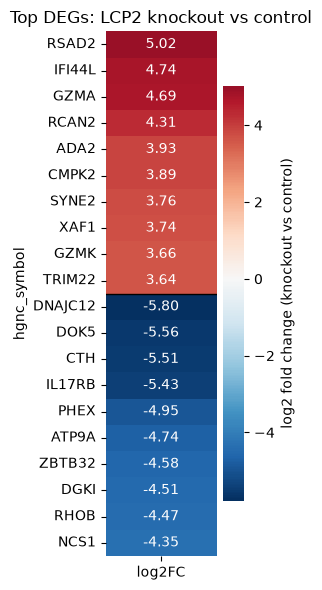

In [22]:
# --- top 10 up- and top 10 down-regulated significant DEGs, by log2FC ---
top_up = significant_degs.sort_values("logfoldchanges", ascending=False).head(10)
top_down = significant_degs.sort_values("logfoldchanges", ascending=True).head(10)
top_genes = pd.concat([top_up, top_down])

logfc_matrix = top_genes.set_index("hgnc_symbol")[["logfoldchanges"]].rename(
    columns={"logfoldchanges": "log2FC"}
)

fig, ax = plt.subplots(figsize=(3, 6))
sns.heatmap(
    logfc_matrix,
    cmap="RdBu_r",
    center=0,                     # 0 = no change, so red/blue = up/down directly
    annot=True, fmt=".2f",
    cbar_kws={"label": "log2 fold change (knockout vs control)"},
    ax=ax,
)
ax.axhline(len(top_up), color="black", linewidth=1)  # separates "up" block from "down" block
ax.set_title(f"Top DEGs: {TARGET_GENE_SYMBOL} knockout vs control")
plt.tight_layout()
plt.savefig('scldm_heatmap_high_res.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
significant_degs.to_csv(OUTPUT_DIR / f"{TARGET_GENE_SYMBOL}_diffexp.csv", index=False)
significant_degs.to_csv("diffexp_genes.csv", index=False)

2026-07-12 19:20:26,616 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-07-12 19:20:26,619 [WARNING] Duplicated values found in preranked stats: 58.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Ranked list: 3689 genes (from 3699 tested)


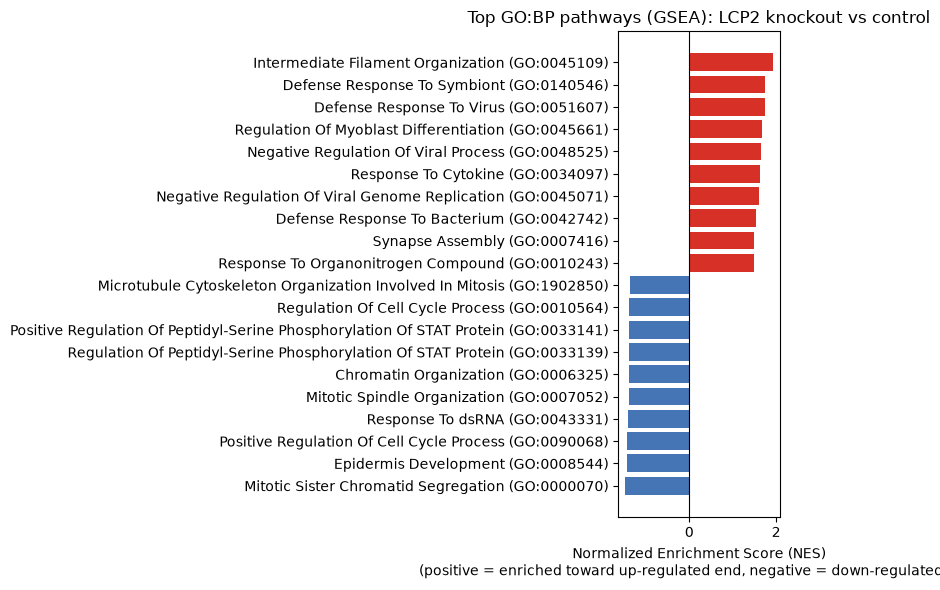

In [19]:
GO_BP_LIBRARY = "GO_Biological_Process_2023"

# --- build the full ranked list: HGNC symbol -> signed test statistic ---
# `scores` is the signed Wilcoxon z-score from rank_genes_groups (positive = up in knockout)
ranked = deg_df[["hgnc_symbol", "scores"]].copy()

# if multiple Ensembl IDs map to the same symbol, keep the most extreme score
ranked = ranked.reindex(ranked["scores"].abs().sort_values(ascending=False).index)
ranked = ranked.drop_duplicates(subset="hgnc_symbol", keep="first")

rnk = ranked[["hgnc_symbol", "scores"]].sort_values("scores", ascending=False)

print(f"Ranked list: {len(rnk)} genes (from {len(deg_df)} tested)")

# --- run preranked GSEA ---
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets=GO_BP_LIBRARY,
    threads=4,
    min_size=5,
    max_size=1000,
    permutation_num=1000,   # lower (e.g. 100) for a quick pass, raise for stable FDR
    outdir=None,
    seed=42,
)

res2d = pre_res.res2d.astype({"NES": float, "FDR q-val": float})

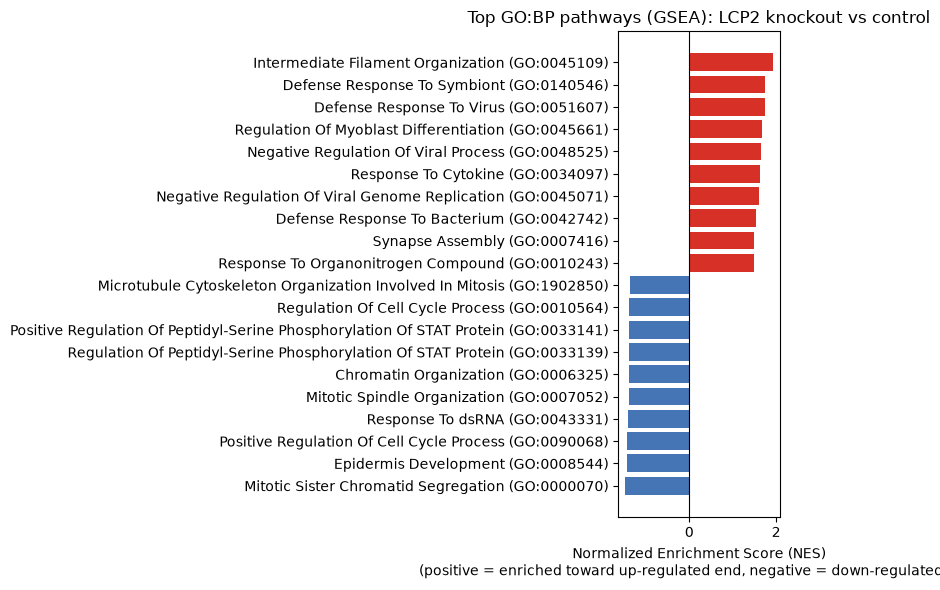

In [21]:
# --- top 10 up (positive NES) and top 10 down (negative NES) pathways ---
top_up_terms = res2d.sort_values("NES", ascending=False).head(10)
top_down_terms = res2d.sort_values("NES", ascending=True).head(10)
plot_df = pd.concat([top_up_terms, top_down_terms]).sort_values("NES")

# --- diverging horizontal bar plot ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#d73027" if nes > 0 else "#4575b4" for nes in plot_df["NES"]]
ax.barh(plot_df["Term"], plot_df["NES"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Normalized Enrichment Score (NES)\n(positive = enriched toward up-regulated end, negative = down-regulated end)")
ax.set_title(f"Top GO:BP pathways (GSEA): {TARGET_GENE_SYMBOL} knockout vs control")
plt.tight_layout()
plt.savefig('scldm_barplot_high_res.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
res2d.to_csv("go_bp_pathways.csv", index=False)

### 7c. Distributional distance in latent space

In [24]:
z_knockout = torch.tensor(knockout_cells.obsm["z"], dtype=torch.float32)
z_control = torch.tensor(control_cells.obsm["z"], dtype=torch.float32)

mmd = MMDLoss(RBFKernel(scale=1.0))(z_knockout, z_control).item()
w_dist = wasserstein(z_knockout, z_control)

print(f"MMD(knockout, control)         = {mmd:.4f}")
print(f"Wasserstein(knockout, control) = {w_dist:.4f}")
print("Larger values => the model predicts a stronger shift away from control under this knockout.")

MMD(knockout, control)         = 0.0040
Wasserstein(knockout, control) = 29.9173
Larger values => the model predicts a stronger shift away from control under this knockout.


In [25]:
pd.DataFrame({"Wasserstein_dist": [w_dist]}).to_csv(OUTPUT_DIR / f"{TARGET_GENE_SYMBOL}_diffexp.csv", index=False)

## 8. Visualize

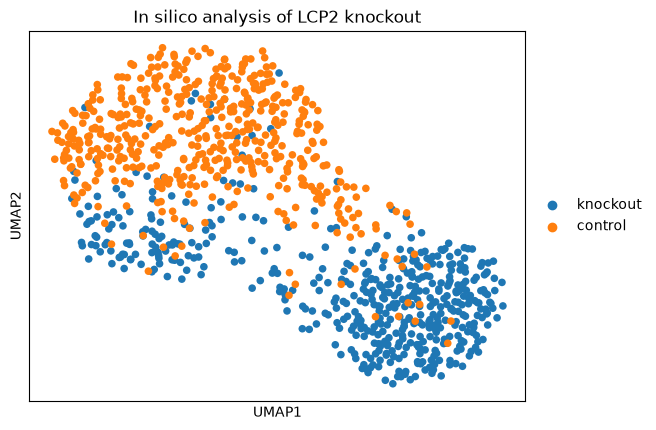

In [26]:
sc.pp.pca(combined)
sc.pp.neighbors(combined)
sc.tl.umap(combined)

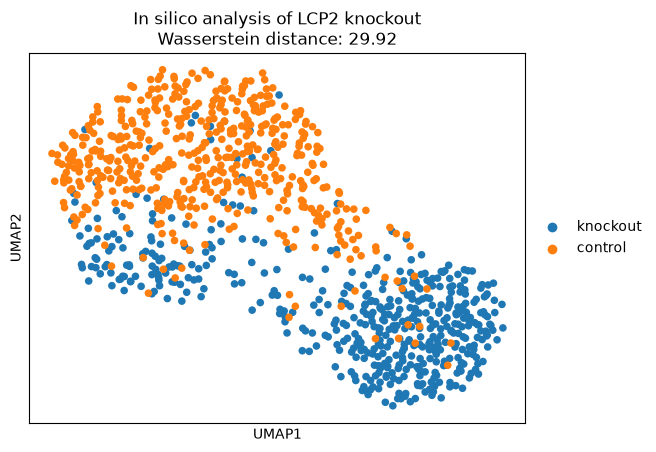

In [28]:
umap = sc.pl.umap(combined, color="group",
           title=f"In silico analysis of {TARGET_GENE_SYMBOL} knockout\nWasserstein distance: {w_dist:.2f}",
            show=False,
          )
plt.savefig('scldm_umap_high_res.png', dpi=300, bbox_inches='tight')
plt.show()